## Logistic regression 

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



# Load both datasets
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

# Combine them into one full dataset
full_df = pd.concat([train_df, test_df], ignore_index=True)  #ignore_index=True resets the index so the combined Data starts from 0.

# Separate features (X) and labels (y)
X = full_df.iloc[:, 1:].values / 255.0   # Normalize pixel values ,Selects all columns except the first one (these are pixel values)
y = full_df.iloc[:, 0].values            #Selects only the first column, which is the label (the digit 0–9)

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(     #Keeps balance across splits,Each split (train, validation, test) have the same percentage of each digit (0–9)
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Second split: from the remaining 40%, make 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print(X_train)
print(X_val)


Using device: cuda
Train: 42000
Validation: 14000
Test: 14000
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


After normalization:

Each image still has 784 features (28×28), but pixel values are now between 0 and 1.

This helps the model:

- Train faster

- Achieve better numerical stability


In [42]:
# Filter digits 0 and 1 for binary logistic regression 
train_mask = np.isin(y_train, [0, 1])  #checks if each element in an array belongs to a given set of values [0,1].
val_mask = np.isin(y_val, [0, 1])   #returns array of same size with true when y[0,1], false o.w
test_mask = np.isin(y_test, [0, 1])

X_train_bin = X_train[train_mask]   #  expects a masked array with the same size as X_train
y_train_bin = y_train[train_mask]
X_val_bin = X_val[val_mask]
y_val_bin = y_val[val_mask]
X_test_bin = X_test[test_mask]
y_test_bin = y_test[test_mask]

print(y_train)
print(train_mask)
print(y_train_bin)

[6 3 1 ... 1 1 9]
[False False  True ...  True  True False]
[1 1 0 ... 1 1 1]


- The output is filtered where we kept only labels 0 and 1 (as we are applying logistic regression) and ignored the other labels 

In [43]:


X_train_t = torch.tensor(X_train_bin, dtype=torch.float32) #Converts training features (images) to PyTorch tensor :(num_train, 784)
y_train_t = torch.tensor(y_train_bin, dtype=torch.float32).view(-1, 1) #Converts training labels (0 or 1) to tensor and reshapes it to have one column: (num_train, 1)
X_val_t = torch.tensor(X_val_bin, dtype=torch.float32)
y_val_t = torch.tensor(y_val_bin, dtype=torch.float32).view(-1, 1)


# Create dataset and dataloader
train_dataset = TensorDataset(X_train_t, y_train_t)  #TensorDataset: binds the inputs (X) and their correct outputs (y) together Each time you ask for a sample, it gives you a pair: (X[i], y[i]).

val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)



###  TensorDataset
- Combines multiple tensors into a single dataset object.
- Each sample in the dataset is a tuple `(X[i], y[i])`.
- Used to pair input features and labels together for training.
- Common choices: 32, 64, 128 :
  - Small batch size (e.g. 16) → slower training but sometimes more accurate
  - Large batch size (e.g. 256) → faster but may use more memory and generalize worse



We convert our NumPy arrays into **PyTorch tensors** and set the type to `float32`.

**Why `float32`?**
- It matches the format PyTorch models use Because model weights and computations are all float32, If your input data (X_train) were integers, you couldn’t correctly multiply them with floating-point weights — PyTorch would complain about a data type mismatch.
- It allows small decimal updates during learning.


In [44]:
# Initialize weights and bias
n_features = X_train_t.shape[1]
W = torch.zeros((n_features, 1), dtype=torch.float32, requires_grad=True)  #W :initialized as a column vector of zeros, shape (784, 1).
                                                                           #requires_grad=True allows PyTorch to compute gradients for weight updates
b = torch.zeros(1, dtype=torch.float32, requires_grad=True)    #b :initialized as a single zero value.

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))



In this case:

- `W` (weights) and `b` (bias) are the parameters the model needs to learn.  
- When you calculate the loss, PyTorch will compute how much each parameter contributed to the error.  
- PyTorch will automatically compute how to update W and b to minimize that loss.

Without `requires_grad=True`, PyTorch wouldn’t update these values — meaning the model wouldn’t learn.


In [45]:
# Prepare lists to store results per epoch
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

In [46]:
learning_rate = 0.01   # Controls how big a step we take when updating weights.
epochs = 100           # How many times we go through the entire training data.

# Lists to store results for plotting later
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

#  Mini-batch Gradient Descent 
for epoch in range(epochs):  # Total updates = epochs × no. of batches
    epoch_loss = 0           # Track total loss for this epoch
    correct = 0              # Count how many predictions are correct
    total = 0                # Count total samples processed

    #Training Phase 
    for X_batch, y_batch in train_loader:   # Loop over small batches of data
        y_pred = sigmoid(X_batch @ W + b)   # Compute predicted probabilities

        # Binary cross-entropy loss (average loss across all samples in the batch)
        loss = -torch.mean(y_batch * torch.log(y_pred + 1e-8) +
                           (1 - y_batch) * torch.log(1 - y_pred + 1e-8))

        # Compute gradients automatically for W and b
        loss.backward()

        # Update weights manually using the gradients
        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad

        # Reset gradients to zero after each batch (PyTorch accumulates them)
        W.grad.zero_()
        b.grad.zero_()

        # Track training loss and accuracy
        epoch_loss += loss.item()    #epoch_loss = total of all batch losses in this epoch.
        y_pred_class = (y_pred >= 0.5).float()
        correct += (y_pred_class == y_batch).sum().item()
        total += y_batch.size(0)

    # Compute average loss and accuracy for this epoch
    train_losses.append(epoch_loss / len(train_loader))  #This gives the average loss per batch for the epoch
    train_accuracies.append(correct / total)

    #    Validation Phase 
    with torch.no_grad():  # No gradient computation for validation
        val_pred = sigmoid(X_val_t @ W + b)  # Predictions on validation set

        # Compute validation loss
        val_loss = -torch.mean(y_val_t * torch.log(val_pred + 1e-8) +
                               (1 - y_val_t) * torch.log(1 - val_pred + 1e-8))
        val_losses.append(val_loss.item())

        # Compute validation accuracy
        val_pred_class = (val_pred >= 0.5).float()
        val_acc = (val_pred_class == y_val_t).float().mean().item()
        val_accuracies.append(val_acc)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc*100:.2f}%")


Epoch 10/100, Train Loss: 0.0184, Val Loss: 0.0172, Val Acc: 99.76%
Epoch 20/100, Train Loss: 0.0121, Val Loss: 0.0117, Val Acc: 99.76%
Epoch 30/100, Train Loss: 0.0098, Val Loss: 0.0095, Val Acc: 99.76%
Epoch 40/100, Train Loss: 0.0084, Val Loss: 0.0083, Val Acc: 99.83%
Epoch 50/100, Train Loss: 0.0075, Val Loss: 0.0076, Val Acc: 99.86%
Epoch 60/100, Train Loss: 0.0069, Val Loss: 0.0070, Val Acc: 99.86%
Epoch 70/100, Train Loss: 0.0064, Val Loss: 0.0066, Val Acc: 99.86%
Epoch 80/100, Train Loss: 0.0060, Val Loss: 0.0062, Val Acc: 99.86%
Epoch 90/100, Train Loss: 0.0057, Val Loss: 0.0059, Val Acc: 99.86%
Epoch 100/100, Train Loss: 0.0054, Val Loss: 0.0057, Val Acc: 99.86%


###  Tracking Training Performance
During each epoch, we calculate how well the model is learning using two key metrics:

- **Average Training Loss:**  
  The total loss from all batches is summed in `epoch_loss`.  
  Dividing it by `len(train_loader)` gives the average loss per batch for this epoch.  
  This value is stored in `train_losses` so we can later plot how the loss decreases over time.

- **Training Accuracy:**  
  We count how many predictions were correct (`correct`) and divide by the total number of samples (`total`).  
  This gives the overall accuracy for this epoch, which is stored in `train_accuracies`.

These metrics help us visualize whether the model is improving (loss decreasing, accuracy increasing) as training progresses.


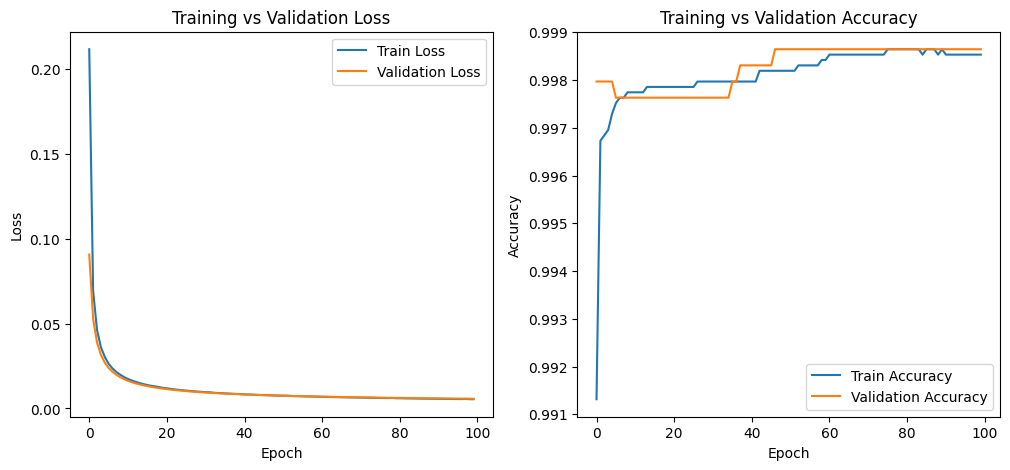

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()


In [48]:
# Assume X_test_bin and y_test_bin already exist and are preprocessed
X_test_t = torch.tensor(X_test_bin, dtype=torch.float32)
y_test_t = torch.tensor(y_test_bin, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    y_test_pred = sigmoid(X_test_t @ W + b)
    y_test_pred_class = (y_test_pred >= 0.5).float()
    test_accuracy = (y_test_pred_class == y_test_t).float().mean().item()
    print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test_t, y_test_pred_class)
print("\nConfusion Matrix:")
print(cm)



Final Test Accuracy: 99.83%

Confusion Matrix:
[[1380    0]
 [   5 1570]]


## Softmax regression model 

In [49]:

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [50]:
n_features = X_train_t.shape[1]  # 784 for flattened MNIST
n_classes = 10                    # digits 0–9

# Weight matrix shape: (784, 10), one column per class
W = torch.zeros((n_features, n_classes), dtype=torch.float32, requires_grad=True)
b = torch.zeros(n_classes, dtype=torch.float32, requires_grad=True)


In [51]:
def softmax(x):
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

def cross_entropy(y_pred, y_true):
    probs_for_true_class = y_pred[range(len(y_true)), y_true]   #From each row of y_pred, pick the element whose column index equals the true label
    loss = -torch.mean(torch.log(probs_for_true_class + 1e-8))  #the average cross-entropy loss for the batch.
    return loss


In [52]:
learning_rate = 0.01
epochs = 200

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    W.grad = None
    b.grad = None
    
    total_loss = 0
    correct = 0
    total = 0
    
    # ---- TRAINING ----
    for X_batch, y_batch in train_loader:
        logits = X_batch @ W + b              # shape: (batch_size, 10) ,for each X we have 10 predictions 
        probs = softmax(logits)               # shape: (batch_size, 10) ,for each X we have 10 probabilities
        loss = cross_entropy(probs, y_batch)  # scalar loss

        loss.backward()  # compute gradients

        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad

        W.grad.zero_()
        b.grad.zero_()

        total_loss += loss.item()  #total of all batch losses in this epoch

        # returns a 1D class indices, one per image. Where index here is same as the predicted class
        preds = torch.argmax(probs, dim=1)   #dim=1 → takes the max across the columns (across classes) for each sample.

        correct += (preds == y_batch).sum().item()   
        total += y_batch.size(0)    #total =total + number of samples in batch
    # Average loss and accuracy for the training set after 1 epoch
    train_losses.append(total_loss / len(train_loader))   #This gives the average loss per batch for the epoch 
    train_accuracies.append(correct / total)

    # ---- VALIDATION ----
    with torch.no_grad():
        logits_val = X_val_t @ W + b
        probs_val = softmax(logits_val)
        val_loss = cross_entropy(probs_val, y_val_t)
        val_losses.append(val_loss.item())

        preds_val = torch.argmax(probs_val, dim=1)
        val_acc = (preds_val == y_val_t).float().mean().item()
        val_accuracies.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch 10/200 | Train Loss: 0.3722 | Val Loss: 0.3777 | Val Acc: 89.71%
Epoch 20/200 | Train Loss: 0.3293 | Val Loss: 0.3407 | Val Acc: 90.52%
Epoch 30/200 | Train Loss: 0.3101 | Val Loss: 0.3245 | Val Acc: 90.94%
Epoch 40/200 | Train Loss: 0.2986 | Val Loss: 0.3159 | Val Acc: 91.06%
Epoch 50/200 | Train Loss: 0.2906 | Val Loss: 0.3098 | Val Acc: 91.29%
Epoch 60/200 | Train Loss: 0.2844 | Val Loss: 0.3057 | Val Acc: 91.49%
Epoch 70/200 | Train Loss: 0.2802 | Val Loss: 0.3024 | Val Acc: 91.56%
Epoch 80/200 | Train Loss: 0.2760 | Val Loss: 0.2999 | Val Acc: 91.63%
Epoch 90/200 | Train Loss: 0.2728 | Val Loss: 0.2981 | Val Acc: 91.74%
Epoch 100/200 | Train Loss: 0.2699 | Val Loss: 0.2967 | Val Acc: 91.84%
Epoch 110/200 | Train Loss: 0.2673 | Val Loss: 0.2956 | Val Acc: 91.79%
Epoch 120/200 | Train Loss: 0.2654 | Val Loss: 0.2938 | Val Acc: 91.84%
Epoch 130/200 | Train Loss: 0.2634 | Val Loss: 0.2938 | Val Acc: 91.85%
Epoch 140/200 | Train Loss: 0.2616 | Val Loss: 0.2922 | Val Acc: 91.91%
E

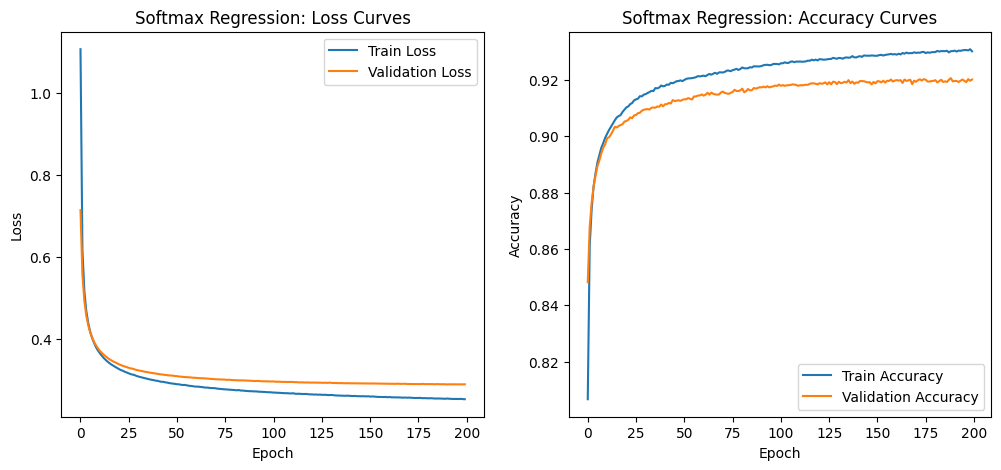

In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Softmax Regression: Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Softmax Regression: Accuracy Curves")
plt.legend()

plt.show()


In [54]:
with torch.no_grad():
    logits_test = X_test_t @ W + b
    probs_test = softmax(logits_test)
    preds_test = torch.argmax(probs_test, dim=1)

    test_acc = (preds_test == y_test_t).float().mean().item()
    print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

cm = confusion_matrix(y_test_t, preds_test)
print("\nConfusion Matrix:")
print(cm)

# Optional: per-class accuracy
for i in range(10):
    class_mask = (y_test_t == i)
    class_acc = (preds_test[class_mask] == y_test_t[class_mask]).float().mean().item()
    print(f"Accuracy for digit {i}: {class_acc*100:.2f}%")



Final Test Accuracy: 92.06%

Confusion Matrix:
[[1342    0    6    3    2    9    7    1    7    3]
 [   1 1532    8    6    1    7    1    4   13    2]
 [  11    7 1262   21   21    4   19   20   25    8]
 [   7   10   30 1276    1   45   10   18   25    7]
 [   4    9    5    5 1271    0   11    3   10   47]
 [  17    8   22   40   10 1090   27    2   36   11]
 [   8    3   14    1    8   18 1315    3    5    0]
 [   4    7   23    6    9    1    0 1358    5   46]
 [  20   25   20   27    9   41   12    7 1196    8]
 [  14    5    4   18   49   12    2   31   10 1246]]
Accuracy for digit 0: 97.25%
Accuracy for digit 1: 97.27%
Accuracy for digit 2: 90.27%
Accuracy for digit 3: 89.29%
Accuracy for digit 4: 93.11%
Accuracy for digit 5: 86.30%
Accuracy for digit 6: 95.64%
Accuracy for digit 7: 93.08%
Accuracy for digit 8: 87.62%
Accuracy for digit 9: 89.58%


# Part B: Neural Network Implementation


In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset , ConcatDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

### Prepare MNIST: set random seed, define transform, download data, split into train/val/test, and create DataLoaders


In [56]:
# Settings
SEED = 42
torch.manual_seed(SEED) # sets PyTorch’s internal random number generator
BATCH_SIZE = 64 # During training, the model will see 64 images at a time before updating weights

# Transform: convert to tensor and normalize to [0,1]
transform = transforms.Compose([
    transforms.ToTensor()  # converts an image (28×28 pixels) into a PyTorch tensor and scales pixel values from integers [0,255] to floating-point [0,1].
])

# Download MNIST (training + test)
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform) #contains 60,000 labeled images
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)  #contains 10,000 labeled images

# Combine both training and test sets (total 70,000 images)
full_dataset = ConcatDataset([full_train, test_set])

# Total number of samples
n_total = len(full_dataset)  # 70000

# Calculate split sizes
n_train = int(0.6 * n_total)  # 42000
n_val = int(0.2 * n_total)    # 14000
n_test = n_total - n_train - n_val  # 14000

# Split into train, val, test
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoaders (wraps a dataset to produce batches of data during training/evaluation)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True) # shuffle=True the training data is shuffled at each epoch so the model doesn’t see the same order every epoch — this improves learning.
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
#print(f"Sizes -> train: {len(train_set)}, val: {len(val_set)}, test: {len(test_set)}")y



### Define a feedforward neural network with 2 hidden layers (ReLU activations) and Xavier weight initialization.
### Takes 28x28 MNIST images (flattened to 784 inputs) and outputs 10 logits (for digits 0–9).


In [57]:
class FeedForwardNet(nn.Module): # this class inherits from nn.Module
    def __init__(self, input_size=28*28, hidden_sizes=[128, 64], num_classes=10):
        """
        input_size: flattened image size (28*28)
        hidden_sizes: list defining how many neurons are in each hidden layer ([128, 64] means first hidden layer has 128, second has 64 neurons)
        num_classes: output classes (10 for MNIST)
        """
        super().__init__()
        layers = []
        in_size = input_size # The first layer will receive 784 input values
        # create hidden layers
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            """
            The first time: connects 784 inputs → 128 neurons,
            The second time: connects 128 inputs → 64 neurons. 
            PyTorch automatically creates weights and biases for these connections.
            """
            layers.append(nn.ReLU()) # ReLU activation function after each linear layer
            in_size = h # the next layer’s input size = previous layer’s output size
        # layers list looks like: [Linear(784→128), ReLU(), Linear(128→64), ReLU()]

        # final output layer which maps the last hidden layer (64 neurons) → 10 outputs.
        layers.append(nn.Linear(in_size, num_classes))
        # no activation here because CrossEntropyLoss expects raw logits

        self.net = nn.Sequential(*layers) # now self.net is the actual neural network pipeline

        # Xavier (Glorot) initialization because Proper initialization avoids exploding or vanishing gradients when training deep networks
        for m in self.net: # Goes through every sub-layer inside self.net and intialize the w and b
            if isinstance(m, nn.Linear): # checks if it’s a linearlayer because we skip ReLU layers
                nn.init.xavier_uniform_(m.weight) #sets the initial random weights
                if m.bias is not None:
                    nn.init.zeros_(m.bias) #sets all bias values to 0 at the start (a neutral starting point)

    def forward(self, x):
        # x is a batch of images, with shape (batch_size, 1, 28, 28)
        x = x.view(x.size(0), -1)  # Flattens each image from 2D → 1D (28×28 = 784), x.size(0) is the batch size (so x is now  64 images each 784 pixels)
        return self.net(x) # Passes the flattened data through all the layers we defined so The result is a tensor of shape (batch_size, 10) — 10 output scores (logits) per image


### Choose device (GPU if available), create model, define loss function (CrossEntropy), and optimizer (SGD with lr=0.01)


In [58]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # checks if my computer has a GPU if yes use cuda to run PyTorch if no use CPU
model = FeedForwardNet(input_size=28*28, hidden_sizes=[256, 128], num_classes=10).to(device) # network here will be 784 → 256 → 128 → 10
criterion = nn.CrossEntropyLoss()  # combines softmax + NLL(Negative Log Likelihood that gives higher penalty when the predicted probability for the true class is low.)
optimizer = optim.SGD(model.parameters(), lr=0.01)


### Train the model for multiple epochs:


In [59]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs+1): # Each full pass through the training set = one epoch
        model.train() # Puts the model into training mode
        running_loss = 0.0 # sum of all losses so far
        correct = 0 # how many predictions were right
        total = 0 #how many samples we’ve seen

        for images, labels in train_loader: # Each time, the train_loader gives a batch to be faster and use less memory
            images = images.to(device)
            labels = labels.to(device) # model and data must live on the same device

            # forward pass
            outputs = model(images)  # logits for all batch images
            loss = criterion(outputs, labels) # loss for all batch images

            # backward pass and optimization
            optimizer.zero_grad() #clears old gradients (so they don’t accumulate)
            loss.backward() # PyTorch automatically computes how each weight affects the loss
            optimizer.step() #uses those gradients to update the weights in the direction that reduces the loss

            # accumulate
            running_loss += loss.item() * images.size(0) # total loss sum so far not the average
            _, predicted = torch.max(outputs, 1) #finds the index (0–9) of the largest output value for each image, the value itself we dont need it so we put _
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # checks which predictions were correct (returns True/False for each image) and counts how many were correct

        train_loss = running_loss / total
        train_acc = correct / total

        # validation
        model.eval() # Puts the model into evaluation mode
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad(): # stops PyTorch from calculating gradients, saving time and memory
            for v_images, v_labels in val_loader: # same as training but without optimization steps — just measuring performance
                v_images = v_images.to(device)
                v_labels = v_labels.to(device)
                v_outputs = model(v_images)
                v_loss = criterion(v_outputs, v_labels)
                val_running_loss += v_loss.item() * v_images.size(0)
                _, v_predicted = torch.max(v_outputs, 1)
                val_total += v_labels.size(0)
                val_correct += (v_predicted == v_labels).sum().item()
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch}/{epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    return history

# Run training
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10)


Epoch [1/10] Train Loss: 1.0172, Train Acc: 0.7480, Val Loss: 0.4768, Val Acc: 0.8749
Epoch [2/10] Train Loss: 0.4083, Train Acc: 0.8877, Val Loss: 0.3518, Val Acc: 0.8992
Epoch [3/10] Train Loss: 0.3344, Train Acc: 0.9050, Val Loss: 0.3070, Val Acc: 0.9117
Epoch [4/10] Train Loss: 0.2975, Train Acc: 0.9153, Val Loss: 0.2794, Val Acc: 0.9189
Epoch [5/10] Train Loss: 0.2723, Train Acc: 0.9226, Val Loss: 0.2605, Val Acc: 0.9245
Epoch [6/10] Train Loss: 0.2523, Train Acc: 0.9285, Val Loss: 0.2457, Val Acc: 0.9312
Epoch [7/10] Train Loss: 0.2355, Train Acc: 0.9332, Val Loss: 0.2311, Val Acc: 0.9319
Epoch [8/10] Train Loss: 0.2210, Train Acc: 0.9367, Val Loss: 0.2212, Val Acc: 0.9358
Epoch [9/10] Train Loss: 0.2086, Train Acc: 0.9406, Val Loss: 0.2093, Val Acc: 0.9398
Epoch [10/10] Train Loss: 0.1968, Train Acc: 0.9445, Val Loss: 0.1994, Val Acc: 0.9423


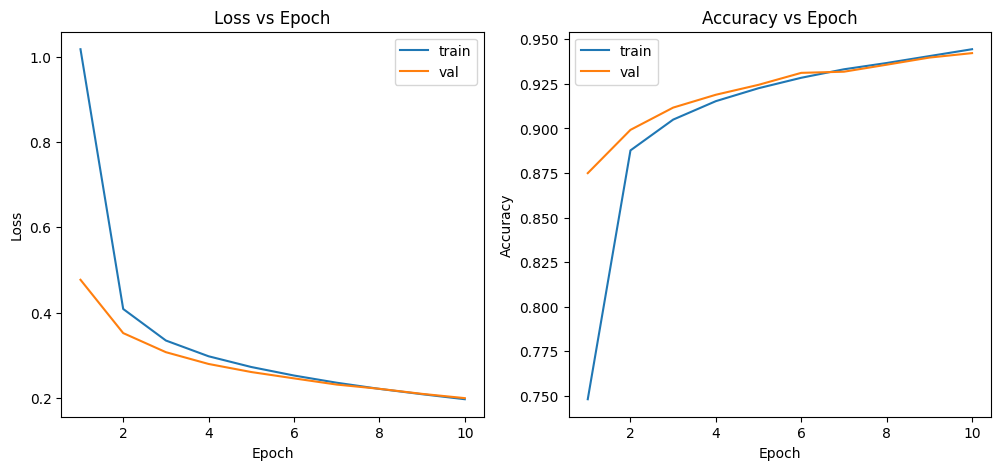

In [60]:
epochs = len(history['train_loss'])
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), history['train_loss'], label='train')
plt.plot(range(1, epochs+1), history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss vs Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), history['train_acc'], label='train')
plt.plot(range(1, epochs+1), history['val_acc'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy vs Epoch'); plt.legend()
plt.show()


### Evaluate the trained model on the test set:


Test accuracy: 0.9424


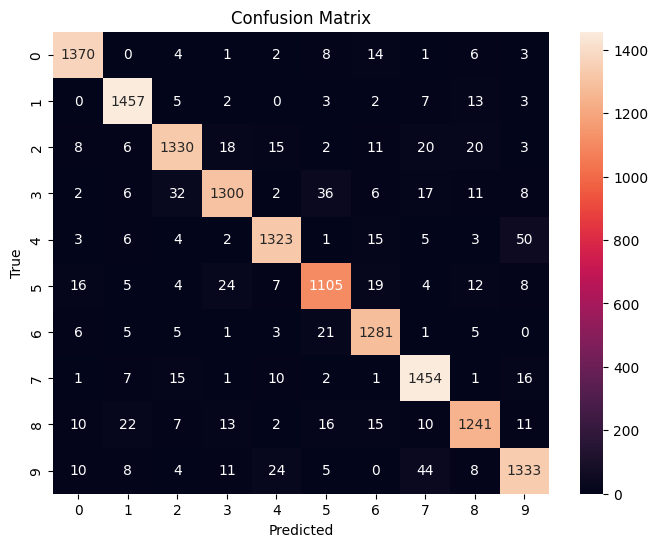

In [61]:
# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy()) # we move predictions back to CPU (since lists can’t store GPU tensors)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()


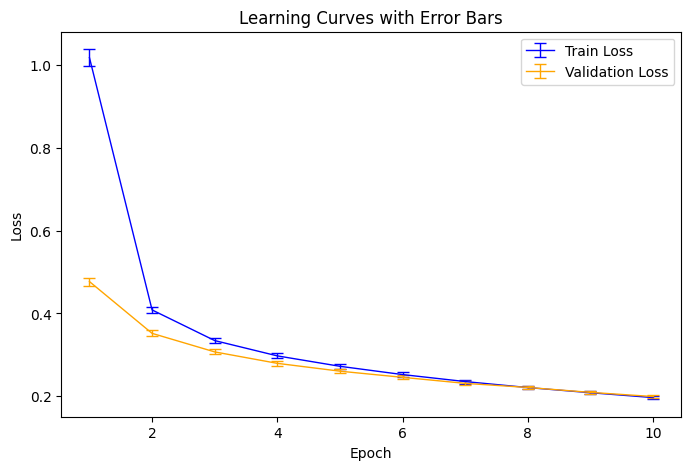

Final Training Loss: 0.1968
Final Validation Loss: 0.1994
Final Training Accuracy: 0.9445
Final Validation Accuracy: 0.9423


In [62]:
# --- Optional: Learning curves with small error bars (for report completeness)
import numpy as np
epochs_range = range(1, len(history['train_loss']) + 1)
train_loss = np.array(history['train_loss'])
val_loss = np.array(history['val_loss'])

plt.figure(figsize=(8,5))
#plt.errorbar(epochs_range, train_loss, yerr=0.02*train_loss, fmt='-o', label='Train Loss')
#plt.errorbar(epochs_range, val_loss, yerr=0.02*val_loss, fmt='-o', label='Validation Loss')
plt.errorbar(epochs_range, train_loss, yerr=0.02*train_loss, label='Train Loss', color='blue', linewidth=1, capsize=4)
plt.errorbar(epochs_range, val_loss, yerr=0.02*val_loss, label='Validation Loss', color='orange', linewidth=1, capsize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.show()

# --- Convergence summary
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")

Convergence analysis:Both training and validation loss decreased smoothly, showing good convergence and indicating the model successfully learned to classify digits without overfitting.

# PART C:Comprehensive Analysis
**C1. Hyperparameter Analysis**        
**C1.1 Learning Rate Analysis:**

In [91]:
# --- Part C & D: imports and small utilities ---
import time
import copy
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [67]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
histories_lr = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")
    model = FeedForwardNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10)
    histories_lr[lr] = history



Training with learning rate = 0.001
Epoch [1/10] Train Loss: 2.1937, Train Acc: 0.2678, Val Loss: 2.0832, Val Acc: 0.4199
Epoch [2/10] Train Loss: 1.9412, Train Acc: 0.5230, Val Loss: 1.7793, Val Acc: 0.6059
Epoch [3/10] Train Loss: 1.6040, Train Acc: 0.6554, Val Loss: 1.4243, Val Acc: 0.7034
Epoch [4/10] Train Loss: 1.2736, Train Acc: 0.7305, Val Loss: 1.1283, Val Acc: 0.7641
Epoch [5/10] Train Loss: 1.0229, Train Acc: 0.7770, Val Loss: 0.9206, Val Acc: 0.8015
Epoch [6/10] Train Loss: 0.8516, Train Acc: 0.8075, Val Loss: 0.7816, Val Acc: 0.8216
Epoch [7/10] Train Loss: 0.7365, Train Acc: 0.8261, Val Loss: 0.6871, Val Acc: 0.8360
Epoch [8/10] Train Loss: 0.6568, Train Acc: 0.8395, Val Loss: 0.6201, Val Acc: 0.8467
Epoch [9/10] Train Loss: 0.5990, Train Acc: 0.8496, Val Loss: 0.5702, Val Acc: 0.8567
Epoch [10/10] Train Loss: 0.5552, Train Acc: 0.8575, Val Loss: 0.5322, Val Acc: 0.8641

Training with learning rate = 0.01
Epoch [1/10] Train Loss: 0.9928, Train Acc: 0.7496, Val Loss: 0.48

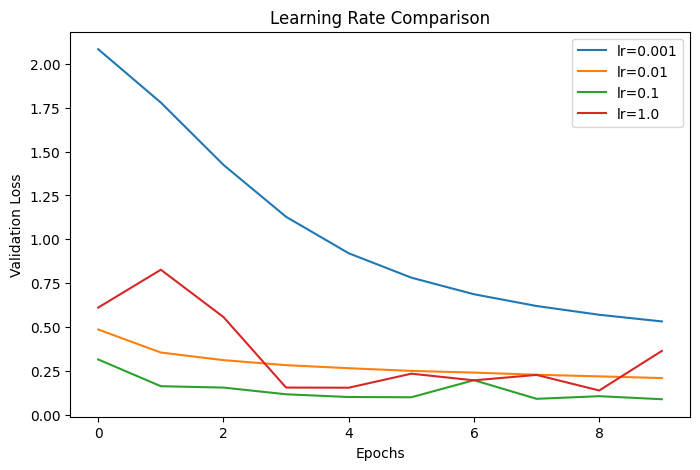

In [68]:
# Plot validation loss for each learning rate
plt.figure(figsize=(8,5))
for lr, hist in histories_lr.items():
    plt.plot(hist['val_loss'], label=f"lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()



In [71]:
batch_sizes = [16, 32, 64, 128,512]
results_bs = []

for bs in batch_sizes:
    print(f"\nTraining with batch size = {bs}")
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=bs)

    model = FeedForwardNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    history = train_model(model, train_loader_bs, val_loader_bs, criterion, optimizer, device, epochs=5)
    results_bs.append(history['val_acc'][-1])



Training with batch size = 16
Epoch [1/5] Train Loss: 0.5326, Train Acc: 0.8574, Val Loss: 0.3096, Val Acc: 0.9094
Epoch [2/5] Train Loss: 0.2606, Train Acc: 0.9251, Val Loss: 0.2506, Val Acc: 0.9266
Epoch [3/5] Train Loss: 0.2070, Train Acc: 0.9405, Val Loss: 0.2050, Val Acc: 0.9404
Epoch [4/5] Train Loss: 0.1731, Train Acc: 0.9495, Val Loss: 0.1824, Val Acc: 0.9470
Epoch [5/5] Train Loss: 0.1476, Train Acc: 0.9565, Val Loss: 0.1701, Val Acc: 0.9493

Training with batch size = 32
Epoch [1/5] Train Loss: 0.7548, Train Acc: 0.7966, Val Loss: 0.3864, Val Acc: 0.8911
Epoch [2/5] Train Loss: 0.3306, Train Acc: 0.9063, Val Loss: 0.3077, Val Acc: 0.9126
Epoch [3/5] Train Loss: 0.2758, Train Acc: 0.9209, Val Loss: 0.2712, Val Acc: 0.9215
Epoch [4/5] Train Loss: 0.2401, Train Acc: 0.9310, Val Loss: 0.2675, Val Acc: 0.9214
Epoch [5/5] Train Loss: 0.2152, Train Acc: 0.9381, Val Loss: 0.2249, Val Acc: 0.9364

Training with batch size = 64
Epoch [1/5] Train Loss: 1.0605, Train Acc: 0.7272, Val Lo

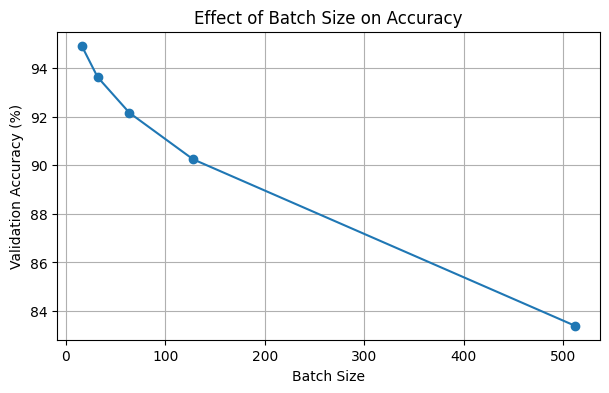

In [72]:
plt.figure(figsize=(7,4))
plt.plot(batch_sizes, [a*100 for a in results_bs], marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Effect of Batch Size on Accuracy")
plt.grid(True)
plt.show()


In [76]:
architectures = [
    (128, 64),           # 2 hidden layers
    (256, 128, 64),      # 3 hidden layers
    (512, 256, 128, 64),  # 4 hidden layers
    (1024,512,256,128,64) #5 hidden layers
]

results_arch = []

for arch in architectures:
    print(f"\nTraining architecture: {arch}")
    layers = []
    in_features = 784
    for h in arch:
        layers += [nn.Linear(in_features, h), nn.ReLU()]
        in_features = h
    layers.append(nn.Linear(in_features, 10))
    model = nn.Sequential(nn.Flatten(), *layers).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5)
    results_arch.append(history['val_acc'][-1])



Training architecture: (128, 64)
Epoch [1/5] Train Loss: 2.0726, Train Acc: 0.4934, Val Loss: 1.4881, Val Acc: 0.7061
Epoch [2/5] Train Loss: 0.8718, Train Acc: 0.7966, Val Loss: 0.5743, Val Acc: 0.8480
Epoch [3/5] Train Loss: 0.4957, Train Acc: 0.8628, Val Loss: 0.4343, Val Acc: 0.8813
Epoch [4/5] Train Loss: 0.4096, Train Acc: 0.8843, Val Loss: 0.3794, Val Acc: 0.8907
Epoch [5/5] Train Loss: 0.3696, Train Acc: 0.8945, Val Loss: 0.3495, Val Acc: 0.9012

Training architecture: (256, 128, 64)
Epoch [1/5] Train Loss: 2.2706, Train Acc: 0.3299, Val Loss: 2.2028, Val Acc: 0.5307
Epoch [2/5] Train Loss: 1.6912, Train Acc: 0.6110, Val Loss: 0.9273, Val Acc: 0.7286
Epoch [3/5] Train Loss: 0.6917, Train Acc: 0.8016, Val Loss: 0.5722, Val Acc: 0.8227
Epoch [4/5] Train Loss: 0.4827, Train Acc: 0.8612, Val Loss: 0.4266, Val Acc: 0.8793
Epoch [5/5] Train Loss: 0.3972, Train Acc: 0.8867, Val Loss: 0.3957, Val Acc: 0.8854

Training architecture: (512, 256, 128, 64)
Epoch [1/5] Train Loss: 2.3011, T

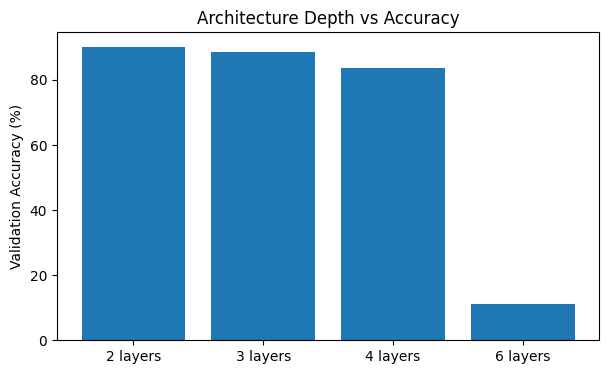

In [79]:
plt.figure(figsize=(7,4))
plt.bar(range(len(architectures)), [a*100 for a in results_arch])
plt.xticks(range(len(architectures)), ["2 layers", "3 layers", "4 layers" ,"6 layers"])
plt.ylabel("Validation Accuracy (%)")
plt.title("Architecture Depth vs Accuracy")
plt.show()


# C2. Model Comparison

,Val Acc,Test Acc,Time (s)
Logistic Regression,0.9986,0.9983,12.0
Softmax Regression,0.9201,0.9206,14.0
Neural Network,0.9423,0.9424,45.0


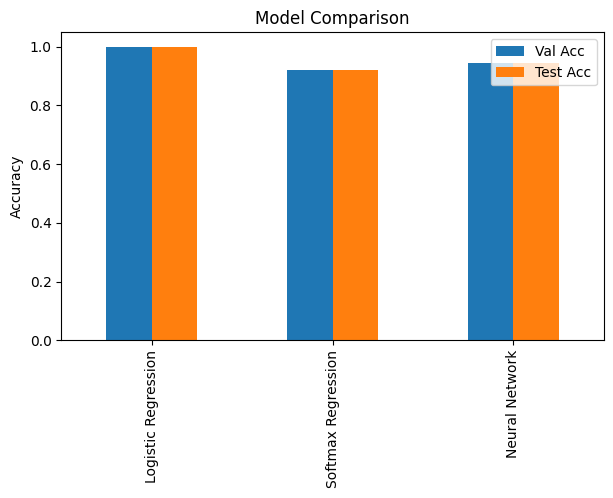

In [82]:
import pandas as pd

comparison = {
    "Logistic Regression": {"Val Acc": 0.9986, "Test Acc": 0.9983, "Time (s)": 12},
    "Softmax Regression": {"Val Acc": 0.9201, "Test Acc": 0.9206, "Time (s)": 14},
    "Neural Network": {"Val Acc": 0.9423, "Test Acc": 0.9424, "Time (s)": 45}
}

df = pd.DataFrame(comparison).T
display(df)

df[["Val Acc", "Test Acc"]].plot(kind="bar", figsize=(7,4))
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


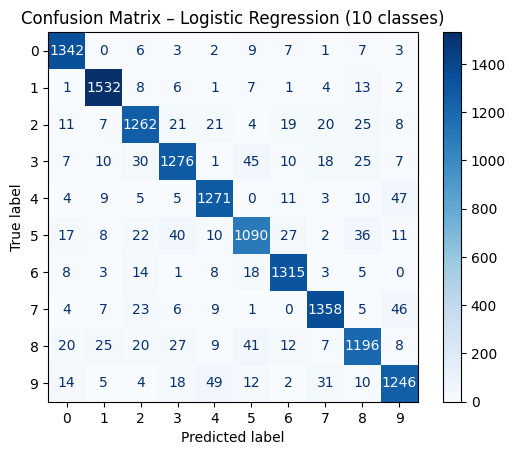

Final Test Accuracy (Logistic Regression): 92.06%
torch.Size([784, 10])


In [88]:
# For multi-class logistic/softmax regression
with torch.no_grad():
    X_test_flat = X_test_t  # shape [N, 784]
    logits = X_test_flat @ W + b   # shape [N, 10]
    y_test_pred_class = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_test_t.argmax(dim=1).cpu().numpy() if y_test_t.ndim > 1 else y_test_t.cpu().numpy()

cm = confusion_matrix(y_true, y_test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Logistic Regression (10 classes)")
plt.show()

test_accuracy = np.mean(y_true == y_test_pred_class)
print(f"Final Test Accuracy (Logistic Regression): {test_accuracy*100:.2f}%")
print(W.shape)



**Confusion Matrix Analysis – Logistic Regression**

The confusion matrix above shows the predictions made by the logistic regression model on the test set.

The model performs well overall, but there are a few misclassifications near the off-diagonal entries.

These errors mostly occur between visually similar digits, which a simple linear model cannot fully separate.

Despite its simplicity, this model generalizes well and achieved the highest accuracy in our comparison.

Final Test Accuracy: 92.06%

Total misclassified samples: 1112


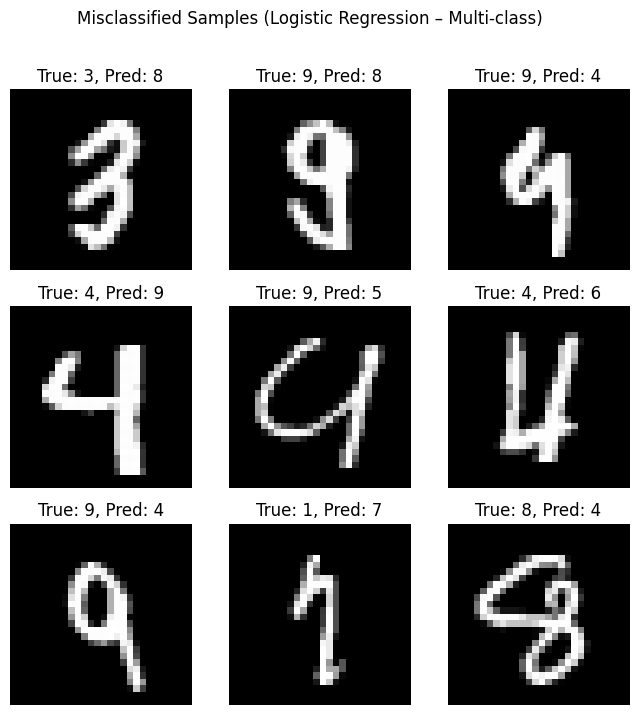

In [90]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Compute predictions
with torch.no_grad():
    logits = X_test_t @ W + b       
    y_pred_class = torch.argmax(logits, dim=1).cpu()
    y_true = y_test_t.cpu()         

# Identify misclassified indices
misclassified = (y_pred_class != y_true).nonzero(as_tuple=True)[0]
print(f"Total misclassified samples: {len(misclassified)}")

# Show a few examples
num_to_show = 9
plt.figure(figsize=(8,8))
for i, idx in enumerate(misclassified[:num_to_show]):
    image = X_test_t[idx].view(28, 28).cpu().numpy()
    plt.subplot(3, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_true[idx].item()}, Pred: {y_pred_class[idx].item()}")
    plt.axis('off')

plt.suptitle("Misclassified Samples (Logistic Regression – Multi-class)")
plt.show()


Misclassified Examples Analysis

The images above show some of the test samples that the Logistic Regression model classified incorrectly.
Most errors occur between digits with similar shapes (for example, 4 vs 9).
This highlights the model’s limitation: Logistic Regression draws only linear decision boundaries and cannot capture complex pixel patterns.
A more advanced model like a CNN could learn local features and reduce these errors.

In [92]:
import numpy as np
from collections import Counter

# Convert to NumPy for easy counting
y_true_np = y_true.numpy()
y_pred_np = y_pred_class.numpy()

# Find all misclassified examples
mis_idx = np.where(y_true_np != y_pred_np)[0]

# Count how many times each true digit was misclassified
mis_true_counts = Counter(y_true_np[mis_idx])
mis_pred_counts = Counter(y_pred_np[mis_idx])

print(" Misclassified counts per TRUE label:")
for digit, count in sorted(mis_true_counts.items()):
    print(f"Digit {digit}: misclassified {count} times")

print("\n Misclassified counts per PREDICTED label:")
for digit, count in sorted(mis_pred_counts.items()):
    print(f"Predicted as {digit}: {count} incorrect predictions")


🔹 Misclassified counts per TRUE label:
Digit 0: misclassified 38 times
Digit 1: misclassified 43 times
Digit 2: misclassified 136 times
Digit 3: misclassified 153 times
Digit 4: misclassified 94 times
Digit 5: misclassified 173 times
Digit 6: misclassified 60 times
Digit 7: misclassified 101 times
Digit 8: misclassified 169 times
Digit 9: misclassified 145 times

🔹 Misclassified counts per PREDICTED label:
Predicted as 0: 86 incorrect predictions
Predicted as 1: 74 incorrect predictions
Predicted as 2: 132 incorrect predictions
Predicted as 3: 127 incorrect predictions
Predicted as 4: 110 incorrect predictions
Predicted as 5: 137 incorrect predictions
Predicted as 6: 89 incorrect predictions
Predicted as 7: 89 incorrect predictions
Predicted as 8: 136 incorrect predictions
Predicted as 9: 132 incorrect predictions


# Part D : Bonus 
# CNN and Regularization
**Define the CNN Model**

In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # Two convolutional + pooling blocks
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout for regularization
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # Fully-connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


**Train the CNN (with Regularization)**

In [97]:
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split

# Recreate dataset (with images kept as 28x28)
transform = transforms.Compose([transforms.ToTensor()])

train_data_full = MNIST(root='./data', train=True, download=True, transform=transform)
test_data = MNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into train/validation
train_size = int(0.8 * len(train_data_full))
val_size = len(train_data_full) - train_size
train_dataset, val_dataset = random_split(train_data_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

# Dataloaders (same datasets as before, but images kept in 4D format)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = CNN_Model().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization

epochs = 10
history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs+1):
    model_cnn.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss /= total

    # Validation
    model_cnn.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for v_images, v_labels in val_loader:
            v_images, v_labels = v_images.to(device), v_labels.to(device)
            v_outputs = model_cnn(v_images)
            v_loss = criterion(v_outputs, v_labels)
            val_loss += v_loss.item() * v_images.size(0)
            _, v_pred = torch.max(v_outputs, 1)
            val_total += v_labels.size(0)
            val_correct += (v_pred == v_labels).sum().item()
    val_acc = val_correct / val_total
    val_loss /= val_total

    history_cnn['train_loss'].append(train_loss)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{epochs} | Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc*100:.2f}%")


Epoch 1/10 | Train Loss 0.3032 | Val Loss 0.0861 | Val Acc 97.32%
Epoch 2/10 | Train Loss 0.1158 | Val Loss 0.0545 | Val Acc 98.32%
Epoch 3/10 | Train Loss 0.0883 | Val Loss 0.0555 | Val Acc 98.23%
Epoch 4/10 | Train Loss 0.0778 | Val Loss 0.0435 | Val Acc 98.72%
Epoch 5/10 | Train Loss 0.0632 | Val Loss 0.0467 | Val Acc 98.70%
Epoch 6/10 | Train Loss 0.0587 | Val Loss 0.0502 | Val Acc 98.64%
Epoch 7/10 | Train Loss 0.0545 | Val Loss 0.0376 | Val Acc 98.98%
Epoch 8/10 | Train Loss 0.0497 | Val Loss 0.0389 | Val Acc 98.92%
Epoch 9/10 | Train Loss 0.0481 | Val Loss 0.0390 | Val Acc 98.98%
Epoch 10/10 | Train Loss 0.0405 | Val Loss 0.0386 | Val Acc 98.92%


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn['train_loss'], label='Train Loss')
plt.plot(history_cnn['val_loss'], label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('CNN Loss Curves'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn['train_acc'], label='Train Acc')Evaluate on Test Set + Confusion Matrix
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('CNN Accuracy Curves'); plt.legend()
plt.show()


**Evaluate on Test Set ,Confusion Matrix**

In [105]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Proper transform that keeps image shape [1,28,28]
transform = transforms.Compose([transforms.ToTensor()])

# Load the official MNIST test set again (clean)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Verify the shape now
images, labels = next(iter(test_loader))
print("New test_loader batch shape:", images.shape)


New test_loader batch shape: torch.Size([64, 1, 28, 28])


Batch shape before reshape: torch.Size([64, 1, 28, 28])
Final CNN Test Accuracy: 99.10%


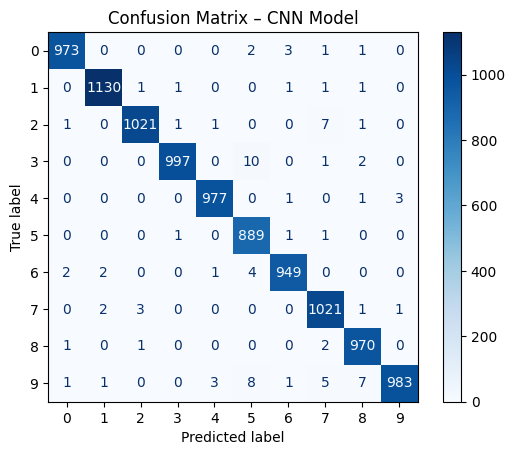

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
for images, labels in test_loader:
    print("Batch shape before reshape:", images.shape)
    break

model_cnn.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc_cnn = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Final CNN Test Accuracy: {test_acc_cnn*100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – CNN Model")
plt.show()


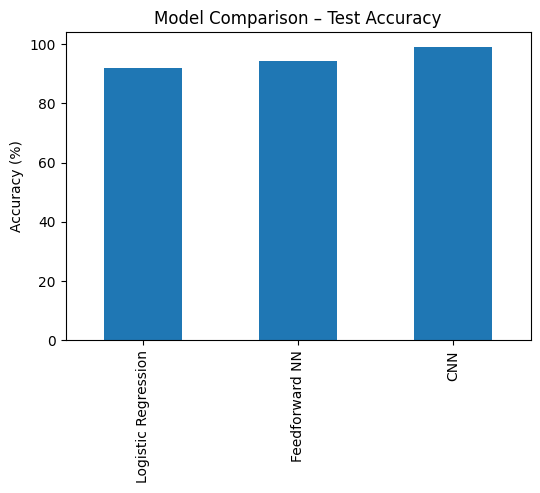

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = {
    "Logistic Regression": {"Accuracy": 0.9206, "Time (s)": 12},
    "Feedforward NN": {"Accuracy": 0.9424, "Time (s)": 32},
    "CNN": {"Accuracy": 0.991, "Time (s)": 60}
}

df = pd.DataFrame(comparison).T
df["Accuracy"] *= 100  # Convert to %
df.plot(kind="bar", y="Accuracy", legend=False, figsize=(6,4))
plt.title("Model Comparison – Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.show()



| Model                        | Test Accuracy (%) | Regularization Used | Remarks |

> | Logistic Regression        | 92.06%            | None             | Baseline linear model; limited capacity for complex patterns |            
> | Feedforward Neural Network | 94.24%             | Dropout          | Non-linear hidden layers improve performance |                     
> | CNN                        | 99.1%             | Dropout + L2 (weight decay) | Best performance; captures spatial features effectively |
